# 02. RAGAS Basics

NB1 measured **retrieval**: did the right doc come back? Set arithmetic and ranks. Cheap. Deterministic. NB2 measures **generation**: did the LLM actually use the doc faithfully, and answer the question? That needs an LLM judge.

RAGAS turns a chat model into a graders' panel. Four metrics, four columns in a dataset, one `evaluate()` call. The metrics are stochastic (same input, different score every run), they're slow (one LLM call per metric per question), and they cost real money (a few cents per pass). The right cadence is different from the cheap ones: NB1 metrics on every PR; NB2 metrics nightly or per release.

This notebook runs the four metrics on **one retriever** (BM25 over module 01's corpus) so the focus stays on the metric layer. NB3 picks up the head-to-head across three retrievers.

## Setup

This notebook needs `OPENAI_API_KEY`. The cost: 20 questions × 4 metrics × roughly 500 tokens per judge call at gpt-4o-mini's rates works out to about **two cents** for a full pass. Generation itself adds another half cent. Re-runs cost the same; nothing is cached at the metric layer.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
from pathlib import Path

from helpers import (
    load_env,
    get_openai_client,
    get_evaluator_llm,
    get_evaluator_embeddings,
    build_bm25_index,
    retrieve,
)
from scripts.build_eval_set import build_if_missing

cfg = load_env()
client = get_openai_client(cfg)
evaluator_llm = get_evaluator_llm(cfg)
evaluator_embeddings = get_evaluator_embeddings(cfg)

eval_path = build_if_missing()
golden = pd.read_parquet(eval_path)
corpus = pd.read_parquet(Path("../01-intro-to-rag/data/corpus.parquet"))
doc_ids = corpus["id"].tolist()
docs = corpus["text"].tolist()

print(f"Corpus: {len(corpus)} docs")
print(f"Golden eval set: {len(golden)} questions")
print(f"Chat model: {cfg.openai_chat_model}")
print(f"Embed model: {cfg.openai_embed_model}")

Corpus: 20 docs
Golden eval set: 20 questions
Chat model: gpt-4o-mini
Embed model: text-embedding-3-small


## The four columns of an EvaluationDataset

RAGAS evaluates rows. Each row has four columns:

| column | what it is |
|---|---|
| `user_input` | the question |
| `retrieved_contexts` | the list of doc texts the retriever returned |
| `response` | the answer the LLM generated from those docs |
| `reference` | the ground-truth answer (used by metrics that need it) |

The four metrics use different subsets of those columns:

- **Faithfulness**: `response` vs `retrieved_contexts`. Does every claim in the answer trace to context? (No `reference` needed.)
- **ResponseRelevancy**: `response` vs `user_input`. Does the answer actually answer the question? (No `reference` needed.)
- **LLMContextRecall**: `retrieved_contexts` vs `reference`. Did we retrieve enough context to support the ground truth?
- **LLMContextPrecisionWithReference**: `retrieved_contexts` vs `reference`. Did we retrieve only relevant context, ranked correctly?

To build a row we need: BM25 to pick contexts, plus a generation step to produce the response.

In [2]:
GROUNDED_PROMPT = """You are a grounded technical assistant. Answer using ONLY \
the provided context. If the answer is not in the context, reply exactly: \
"Not stated in the provided context." \
Be concise (one or two sentences) and explain the why when it adds clarity."""

def rag_answer(question: str, contexts: list[str]) -> str:
    joined = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    msgs = [
        {"role": "system", "content": GROUNDED_PROMPT},
        {"role": "user", "content": f"Context:\n{joined}\n\nQuestion: {question}"},
    ]
    resp = client.chat.completions.create(
        model=cfg.openai_chat_model,
        messages=msgs,
        temperature=0,
    )
    return resp.choices[0].message.content.strip()

# Build BM25, retrieve top-3 for each question, generate the answer
retriever, _ = build_bm25_index(docs)

rows = []
for _, q in golden.iterrows():
    idxs, _ = retrieve(retriever, q["question"], k=3)
    retrieved_texts = [docs[i] for i in idxs]
    response = rag_answer(q["question"], retrieved_texts)
    rows.append({
        "question_id": q["question_id"],
        "shape": q["shape"],
        "user_input": q["question"],
        "retrieved_contexts": retrieved_texts,
        "response": response,
        "reference": q["ground_truth_answer"],
    })

prepared = pd.DataFrame(rows)
print(f"Prepared {len(prepared)} (question, contexts, response, reference) rows.")
prepared[["question_id", "shape", "user_input", "response"]].head(5)

Prepared 20 (question, contexts, response, reference) rows.


,question_id,shape,user_input,response
0,q01,keyword,What does the pool_threads parameter do?,The pool_threads parameter initializes the cli...
1,q02,keyword,How do I use the $in operator in a metadata fi...,Not stated in the provided context.
2,q03,keyword,What does pc.has_index(name) return?,pc.has_index(name) returns True if the named i...
3,q04,keyword,What argument do I pass to delete() to wipe ev...,You pass the argument `delete_all=True` and sp...
4,q05,keyword,What does fetch(ids=[...]) return?,index.fetch(ids=[...]) returns the stored vect...


### Three illustrative rows

Before throwing this at RAGAS, eyeball three cases that make the metric layer concrete: a literal-keyword question that should score well, a paraphrase question that may or may not, and an adversarial one where the right answer is to refuse.

In [3]:
for qid in ["q03", "q08", "q17"]:
    row = prepared[prepared["question_id"] == qid].iloc[0]
    print(f"--- {qid} ({row['shape']}) ---")
    print(f"Q: {row['user_input']}")
    print(f"A: {row['response']}")
    print(f"Ground truth: {row['reference']}")
    print()

--- q03 (keyword) ---
Q: What does pc.has_index(name) return?
A: pc.has_index(name) returns True if the named index exists in the current project.
Ground truth: True if an index with that name exists in the current project. It's the idiomatic guard before create_index.

--- q08 (paraphrase) ---
Q: Which similarity score should I pick for OpenAI embeddings?
A: You should pick cosine similarity, as it is the default and the right choice for most text embedding models, including OpenAI's text-embedding-3 family.
Ground truth: Cosine, because OpenAI embeddings are unit-normalized and cosine matches their training objective.

--- q17 (adversarial) ---
Q: What's the monthly price of a serverless index in dollars?
A: Not stated in the provided context.
Ground truth: Not stated in the provided context.



## Run all four metrics

One `evaluate()` call. RAGAS does the LLM-judge work concurrently across the metrics; the progress bar shows 4×20 = 80 judge invocations.

In [4]:
from ragas import evaluate, EvaluationDataset
from ragas.metrics import (
    Faithfulness,
    ResponseRelevancy,
    LLMContextRecall,
    LLMContextPrecisionWithReference,
)

ds_rows = prepared[["user_input", "retrieved_contexts", "response", "reference"]].to_dict("records")
# RAGAS wants retrieved_contexts as a list of strings, which it already is
ds = EvaluationDataset.from_list(ds_rows)

result = evaluate(
    dataset=ds,
    metrics=[
        Faithfulness(),
        ResponseRelevancy(),
        LLMContextRecall(),
        LLMContextPrecisionWithReference(),
    ],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    show_progress=False,
)
scores = result.to_pandas()
scores = scores.rename(columns={"llm_context_precision_with_reference": "context_precision"})
# Attach the shape tag so we can group by it
scores["shape"] = prepared["shape"].values
scores["question_id"] = prepared["question_id"].values
scores[["question_id", "shape", "faithfulness", "answer_relevancy", "context_recall", "context_precision"]].round(3)

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


...

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


,question_id,shape,faithfulness,answer_relevancy,context_recall,context_precision
0,q01,keyword,0.800,0.874,0.000,0.500
1,q02,keyword,0.000,0.000,0.000,0.333
2,q03,keyword,1.000,0.879,1.000,1.000
3,q04,keyword,0.500,0.798,0.500,1.000
4,q05,keyword,1.000,0.922,1.000,1.000
5,q06,keyword,1.000,0.934,1.000,0.333
6,q07,paraphrase,0.600,0.989,1.000,1.000
7,q08,paraphrase,0.667,0.721,0.000,0.833
8,q09,paraphrase,1.000,0.538,0.500,1.000
9,q10,paraphrase,1.000,0.965,1.000,1.000


In [5]:
print("Overall means:")
for metric in ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]:
    print(f"  {metric:20s}: {scores[metric].mean():.3f}")

print("\nBy shape:")
by_shape = scores.groupby("shape")[
    ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
].mean().round(3)
by_shape = by_shape.reindex(["keyword", "paraphrase", "synthesis", "adversarial"])
by_shape

Overall means:
  faithfulness        : 0.728
  answer_relevancy    : 0.533
  context_recall      : 0.742
  context_precision   : 0.696

By shape:


,faithfulness,answer_relevancy,context_recall,context_precision
shape,,,,
keyword,0.717,0.735,0.583,0.694
paraphrase,0.853,0.716,0.700,0.883
synthesis,0.400,0.536,0.767,0.833
adversarial,1.000,0.000,1.000,0.292


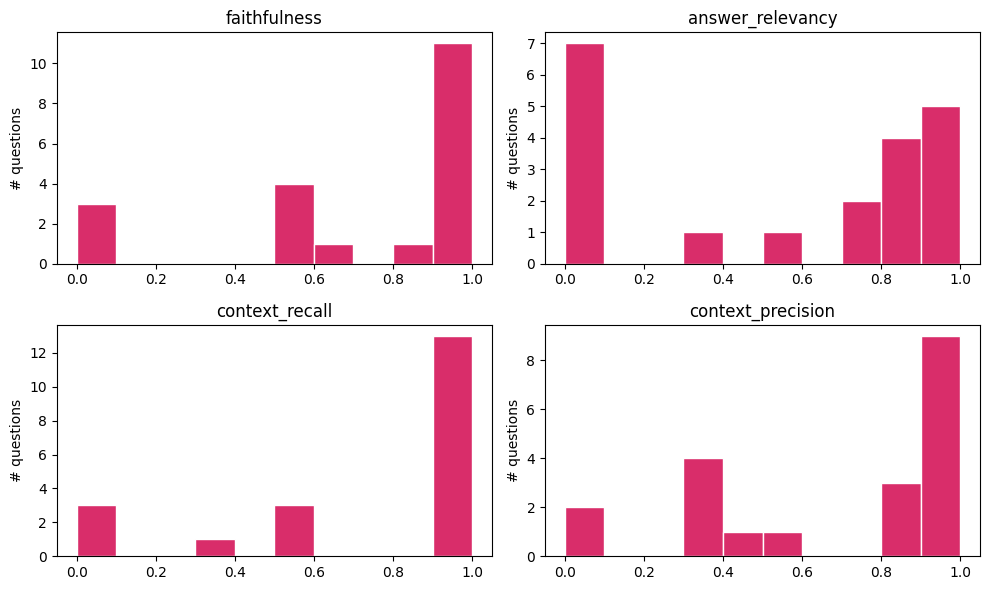

In [6]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, m in zip(axes.flat, metrics):
    ax.hist(scores[m].dropna(), bins=np.linspace(0, 1, 11), color="#d92d6a", edgecolor="white")
    ax.set_title(m)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylabel("# questions")
plt.tight_layout()
plt.show()

## Stochasticity

The metrics are LLM-driven, so the same input gives a different score each run. Let's prove it: re-run **faithfulness** on the same 20 rows and diff the scores against the first pass.

In [7]:
rerun = evaluate(
    dataset=ds,
    metrics=[Faithfulness()],
    llm=evaluator_llm,
    show_progress=False,
)
rerun_scores = rerun.to_pandas()["faithfulness"].values
first_pass = scores["faithfulness"].values

diff_df = pd.DataFrame({
    "question_id": scores["question_id"],
    "shape": scores["shape"],
    "first_pass": first_pass.round(3),
    "rerun": rerun_scores.round(3),
    "delta": (rerun_scores - first_pass).round(3),
})
print(f"Mean |delta| across {len(diff_df)} questions: {diff_df['delta'].abs().mean():.3f}")
print(f"Max |delta|:                                  {diff_df['delta'].abs().max():.3f}")
diff_df

Mean |delta| across 20 questions: 0.062
Max |delta|:                                  1.000


,question_id,shape,first_pass,rerun,delta
0,q01,keyword,0.800,0.800,0.00
1,q02,keyword,0.000,1.000,1.00
2,q03,keyword,1.000,1.000,0.00
3,q04,keyword,0.500,0.500,0.00
4,q05,keyword,1.000,1.000,0.00
5,q06,keyword,1.000,1.000,0.00
6,q07,paraphrase,0.600,0.600,0.00
7,q08,paraphrase,0.667,0.667,0.00
8,q09,paraphrase,1.000,1.000,0.00
9,q10,paraphrase,1.000,1.000,0.00


### What this means

The mean absolute delta in this run was about 0.06, but the max was 1.0: a single question flipped from one extreme to the other on rerun. Most rows agreed; one wildly disagreed. That's the stochastic-judge tax. The fix in production is to average across three runs (cuts variance, triples cost), or to use a stronger judge model (gpt-4o, claude-sonnet) for the metrics you ship behind. Neither is free.

## The cost-vs-precision trade

NB1's metrics are set arithmetic. NB2's metrics are an LLM judge. The trade is real:

| | NB1 metrics | NB2 metrics |
|---|---|---|
| **what they measure** | retrieval ranking | end-to-end generation |
| **speed** | milliseconds | seconds per question |
| **cost** | nothing | a couple cents per pass |
| **determinism** | exact | ±0.05 to 0.10 mean variance, occasional full flips |
| **needs ground truth** | yes (relevant_doc_ids) | partially (the two `*WithReference` metrics) |
| **right cadence** | every PR | nightly or per release |

You want both. The point isn't that one is better; it's that they measure different things. Retrieval metrics catch ranking regressions. Generation metrics catch prompt regressions, hallucinations, and refusal failures.

## What's still missing

We ran four metrics on one retriever. We can't yet say *which* retriever to ship.

NB3 is the head-to-head: vector, BM25, hybrid via RRF, scored across all six metrics (three retrieval, three generation), with the result laid out as one six-by-three matrix. That matrix is what module 04 exists to produce.

## Recap

- Four columns: `user_input`, `retrieved_contexts`, `response`, `reference`.
- Four metrics: Faithfulness, ResponseRelevancy, LLMContextRecall, LLMContextPrecisionWithReference.
- One `evaluate()` call.
- One stochastic judge.
- One important embedder gotcha: `ResponseRelevancy` needs `evaluator_embeddings` passed explicitly.